# 01 — Merge Sources
Build per-coin 5-minute Parquet files by joining all raw data sources onto a common UTC timestamp index.

| # | Notebook | Reads → Writes |
|---|----------|----------------|
| **▶ 01** | **Merge Raw Data** | `raw/` → `merged/{coin}_5m_raw.parquet` |
| 02 | Clean & Label | `merged/` → `cleansed/{coin}_5m.parquet` |
| 03 | EDA | `cleansed/` |
| 03b | EDA — Downside Depegs | `cleansed/` |
| 04 | Feature Engineering | `cleansed/` → `features/{coin}_5m_features.parquet` |
| 05 | Build Pooled Dataset | `features/` → `features/pooled_5m.parquet` |
| 06 | Feature-Level EDA | `features/pooled_5m.parquet` |
| 07 | Depeg Event Study | `features/{coin}_5m_features.parquet` |
| 08 | Feature Selection | `features/pooled_5m.parquet` → `features/selected_features.json` |
| 09 | Baseline Models | `features/pooled_5m.parquet` + `selected_features.json` → model results |
| 10 | Final Model (CatBoost) | + `selected_features.json` → `data/models/nb10_catboost.cbm` + `nb10_meta.json` |
| 11 | Threshold & Ops | `data/models/nb10_meta.json` → threshold, alert metrics |
| 12 | LOEO Validation | `data/models/nb10_meta.json` → leave-one-event-out results |
This is a pure join — no cleaning, gap-filling, or derived columns. That happens in `02_clean_merged_data.ipynb`.

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# ── Environment detection ─────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Running in Google Colab — Drive mounted at /content/drive")
else:
    print("Running locally")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

Running locally


## Configuration
Set output paths here before running the notebook.

In [2]:
DRIVE_PROJECT_PATH = "MyDrive/Capstone"   # ← Colab: path inside Google Drive
LOCAL_PROJECT_PATH = None                 # ← Local: set explicit path or None for auto-detect

if IN_COLAB:
    ROOT = Path("/content/drive") / DRIVE_PROJECT_PATH
elif LOCAL_PROJECT_PATH is not None:
    ROOT = Path(LOCAL_PROJECT_PATH)
else:
    # Auto-detect: walk up from cwd until we find config/settings.py
    _candidates = [Path.cwd()] + list(Path.cwd().parents)
    ROOT = next((p for p in _candidates if (p / "config" / "settings.py").exists()), None)
    if ROOT is None:
        raise FileNotFoundError(
            "Could not find project root (looked for config/settings.py). "
            "Set LOCAL_PROJECT_PATH above or run from within the project directory."
        )

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

RAW_DIR = ROOT / "data" / "raw"
OUT_DIR = ROOT / "data" / "processed" / "merged"   # ← change output location if needed

GLOBAL_END_DATE = pd.Timestamp("2026-02-28 23:55:00", tz="UTC")

OUT_DIR.mkdir(parents=True, exist_ok=True)

from config.settings import STABLECOINS
COINS = list(STABLECOINS.keys())

print(f"Project root: {ROOT}")
print(f"Raw data:     {RAW_DIR}")
print(f"Output dir:   {OUT_DIR}")
print(f"End date:     {GLOBAL_END_DATE}")
print(f"Coins:        {COINS}")

Project root: /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global
Raw data:     /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/raw
Output dir:   /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/processed/merged
End date:     2026-02-28 23:55:00+00:00
Coins:        ['usdt', 'usdc', 'dai', 'busd', 'ust', 'usde', 'rlusd']


## Load & Merge Functions
All data loading and merge logic defined inline — no hidden imports from `src/`.

In [3]:
def build_5m_index(start, end):
    return pd.date_range(start=start, end=end, freq="5min", tz="UTC")


def load_coinapi(coin_key):
    files = list((RAW_DIR / "coinapi").glob(f"{coin_key}_*.parquet"))
    if not files:
        return pd.DataFrame()
    dfs = []
    for f in files:
        df = pd.read_parquet(f)
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
        df = df.rename(columns={c: f"coinapi_{c}" for c in
                                 ["open","high","low","close","volume","trades","tick_count"]
                                 if c in df.columns})
        df = df.drop(columns=["symbol_id","index_id"], errors="ignore")
        dfs.append(df.set_index("timestamp"))
    return pd.concat(dfs, axis=1).sort_index()


def load_binance(coin_key):
    files = [f for f in (RAW_DIR / "binance").glob(f"{coin_key}_*.parquet")
             if not any(m in f.stem.upper() for m in ["BTCUSDT","ETHUSDT"])]
    if not files:
        return pd.DataFrame()
    dfs = []
    for f in files:
        df = pd.read_parquet(f)
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
        symbol = df["symbol"].iloc[0].lower() if "symbol" in df.columns else f.stem
        df = df.rename(columns={c: f"binance_{symbol}_{c}" for c in
                                  ["open","high","low","close","volume","quote_volume",
                                   "trades","taker_buy_volume","taker_buy_quote_volume",
                                   "buy_ratio","spread_proxy"] if c in df.columns})
        df = df.drop(columns=["symbol"], errors="ignore")
        dfs.append(df.set_index("timestamp"))
    return pd.concat(dfs, axis=1).sort_index()


def load_btc_eth_5m():
    frames = []
    for fname, col in [("usdt_btcusdt.parquet", "binance_btc_close"),
                        ("usdt_ethusdt.parquet", "binance_eth_close")]:
        path = RAW_DIR / "binance" / fname
        if not path.exists():
            continue
        df = pd.read_parquet(path)
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
        frames.append(df.set_index("timestamp")[["close"]].rename(columns={"close": col}))
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, axis=1).sort_index()


def load_fred():
    path = RAW_DIR / "fred" / "macro.parquet"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_parquet(path)
    df["date"] = pd.to_datetime(df["date"], utc=True)
    return df.set_index("date").sort_index()


def load_market():
    path = RAW_DIR / "market" / "market_daily.parquet"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_parquet(path)
    df["date"] = pd.to_datetime(df["date"], utc=True)
    return df.set_index("date").sort_index()


def load_onchain(coin_key):
    path = RAW_DIR / "onchain" / f"{coin_key}_eth_5m.parquet"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_parquet(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    return df.set_index("timestamp").sort_index()


def load_tron(coin_key):
    if coin_key != "usdt":
        return pd.DataFrame()
    path = RAW_DIR / "onchain" / "usdt_tron_5m.parquet"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_parquet(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df = df.rename(columns={c: f"tron_{c}" for c in df.columns if c != "timestamp"})
    return df.set_index("timestamp").sort_index()


def load_omni(coin_key):
    """Omni Layer (Bitcoin) treasury flows — USDT only.
    In 2017-2021 Omni was the dominant USDT chain; institutional redemptions
    sent USDT back to the treasury wallet on-chain before Tether processed the
    USD wire. This provides the leading redemption-pressure signal for that era.
    """
    if coin_key != "usdt":
        return pd.DataFrame()
    path = RAW_DIR / "omni" / "usdt_omni_5m.parquet"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_parquet(path)
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
        df = df.set_index("timestamp")
    df.index = pd.to_datetime(df.index, utc=True)
    return df.sort_index()


def load_xrpl(coin_key):
    if coin_key != "rlusd":
        return pd.DataFrame()
    path = RAW_DIR / "onchain" / "rlusd_xrpl_5m.parquet"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_parquet(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    return df.set_index("timestamp").sort_index()


def load_solana(coin_key):
    if coin_key != "usdc":
        return pd.DataFrame()
    path = RAW_DIR / "onchain" / "usdc_sol_5m.parquet"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_parquet(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    return df.set_index("timestamp").sort_index()


_CURVE_POOL_COINS = {
    "3pool":             ["usdt","usdc","dai"],
    "busd_3crv":         ["busd"],
    "ust_3crv":          ["ust"],
    "ust_wormhole_3crv": ["ust"],
    "usde_usdc":         ["usde"],
    "rlusd_usdc":        ["rlusd"],
}

def load_curve(coin_key):
    frames = []
    for pool, coins in _CURVE_POOL_COINS.items():
        if coin_key not in coins:
            continue
        path = RAW_DIR / "curve" / f"{pool}_5m.parquet"
        if not path.exists():
            continue
        df = pd.read_parquet(path)
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
        df = df.rename(columns={c: f"curve_{pool}_{c}" for c in df.columns if c != "timestamp"})
        frames.append(df.set_index("timestamp").sort_index())
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, axis=1).sort_index()


def merge_coin(coin_key):
    config = STABLECOINS[coin_key]
    sources_5m = {
        "coinapi":  load_coinapi(coin_key),
        "binance":  load_binance(coin_key),
        "onchain":  load_onchain(coin_key),
        "tron":     load_tron(coin_key),
        "omni":     load_omni(coin_key),
        "xrpl":     load_xrpl(coin_key),
        "solana":   load_solana(coin_key),
        "curve":    load_curve(coin_key),
    }
    available = [df for df in sources_5m.values() if not df.empty]
    if not available:
        print(f"  No 5m data found for {coin_key}")
        return pd.DataFrame()

    start = min(df.index.min() for df in available)
    end   = max(df.index.max() for df in available)
    print(f"  5m index: {start.date()} → {end.date()}")

    result = pd.DataFrame(index=build_5m_index(start, end))
    result.index.name = "timestamp"

    for name, df in sources_5m.items():
        if not df.empty:
            result = result.join(df, how="left")
            print(f"    {name}: {len(df):,} rows joined")

    btc_eth = load_btc_eth_5m()
    if not btc_eth.empty:
        result = result.join(btc_eth, how="left")
        print(f"    btc/eth: {len(btc_eth):,} rows joined")

    for name, daily_df in [("fred", load_fred()), ("market", load_market())]:
        if daily_df.empty:
            continue
        daily_df = daily_df.ffill()
        result = result.join(daily_df.reindex(result.index, method="ffill"), how="left")
        print(f"    {name}: {len(daily_df)} daily rows → forward-filled to 5m")

    result["date"]        = result.index.date
    result["time"]        = result.index.time
    result["coin"]        = coin_key
    result["peg"]         = config["peg"]
    result["coin_type"]   = config["type"]
    result["coin_status"] = config["status"]

    # Trim to coin's active date range + global cutoff
    result = result[result.index >= pd.Timestamp(config["start_date"], tz="UTC")]
    if config.get("end_date"):
        result = result[result.index <= pd.Timestamp(config["end_date"], tz="UTC")]
    result = result[result.index <= GLOBAL_END_DATE].sort_index()

    print(f"  Final shape: {result.shape}")
    return result


print("Load & merge functions defined.")

Load & merge functions defined.


## 1. Raw Source Inventory
Summarise every raw source file — row counts, date ranges, and column counts — before any joining takes place.

In [4]:
def summarise_df(name, df, ts_col=None):
    """Return a summary dict for a loaded DataFrame."""
    if df is None or df.empty:
        return {"source": name, "rows": 0, "start": "—", "end": "—", "columns": 0}
    idx = df.index if ts_col is None else df[ts_col]
    return {
        "source": name,
        "rows": len(df),
        "start": str(idx.min())[:10],
        "end": str(idx.max())[:10],
        "columns": df.shape[1],
    }

rows = []

# Shared daily sources
rows.append(summarise_df("FRED macro",    load_fred()))
rows.append(summarise_df("Market daily",  load_market()))
rows.append(summarise_df("BTC/ETH 5m",   load_btc_eth_5m()))

# Per-coin 5m sources
for coin in COINS:
    for loader, label in [
        (load_coinapi,  "CoinAPI VWAP"),
        (load_binance,  "Binance OHLCV"),
        (load_onchain,  "On-chain ETH"),
        (load_tron,     "TRON treasury"),
        (load_xrpl,     "XRPL"),
        (load_solana,   "Solana"),
        (load_curve,    "Curve DEX"),
    ]:
        df = loader(coin)
        if not df.empty:
            rows.append(summarise_df(f"{coin.upper()} — {label}", df))

inv = pd.DataFrame(rows)
inv["rows"] = inv["rows"].apply(lambda x: f"{x:,}" if isinstance(x, int) else x)
inv.style.set_caption("Raw Source Inventory").set_table_styles(
    [{"selector": "th", "props": [("background-color", "#1A2E4A"), ("color", "white")]}]
)

,source,rows,start,end,columns
0,FRED macro,"2,892",2015-01-01,2026-02-27,4
1,Market daily,"2,949",2018-02-01,2026-03-03,1
2,BTC/ETH 5m,"895,978",2017-08-17,2026-02-28,2
3,USDT — CoinAPI VWAP,"919,434",2017-06-01,2026-03-03,5
4,USDT — Binance OHLCV,"709,267",2018-12-15,2026-02-28,11
5,USDT — On-chain ETH,"8,703",2017-11-28,2026-02-28,10
6,USDT — TRON treasury,"9,599",2019-04-16,2026-02-28,5
7,USDT — Curve DEX,"277,828",2020-09-06,2026-03-02,15
8,USDC — CoinAPI VWAP,"775,108",2018-10-16,2026-03-03,5
9,USDC — Binance OHLCV,"713,273",2018-12-15,2026-03-11,33


## 2. Source Coverage by Coin
Which sources are available for each coin, and how far back do they go?

In [5]:
SOURCE_LOADERS = {
    "CoinAPI": load_coinapi,
    "Binance":  load_binance,
    "On-chain ETH": load_onchain,
    "TRON": load_tron,
    "Omni (Bitcoin)": load_omni,
    "XRPL": load_xrpl,
    "Solana": load_solana,
    "Curve DEX": load_curve,
}

coverage = []
for coin in COINS:
    row = {"coin": coin.upper()}
    for label, loader in SOURCE_LOADERS.items():
        df = loader(coin)
        row[label] = f"{df.index.min().date()} → {df.index.max().date()}" if not df.empty else "—"
    coverage.append(row)

pd.DataFrame(coverage).set_index("coin").style.set_caption(
    "Date coverage per source (— = not applicable)"
).set_table_styles(
    [{"selector": "th", "props": [("background-color", "#1A2E4A"), ("color", "white")]}]
)

,CoinAPI,Binance,On-chain ETH,TRON,Omni (Bitcoin),XRPL,Solana,Curve DEX
coin,,,,,,,,
USDT,2017-06-01 → 2026-03-03,2018-12-15 → 2026-02-28,2017-11-28 → 2026-02-28,2019-04-16 → 2026-02-28,2017-11-26 → 2025-09-17,—,—,2020-09-06 → 2026-03-02
USDC,2018-10-16 → 2026-03-03,2018-12-15 → 2026-03-11,2018-09-10 → 2026-03-02,—,—,—,2020-10-16 → 2026-03-12,2020-09-06 → 2026-03-02
DAI,2018-04-13 → 2026-03-03,—,2019-11-13 → 2026-03-02,—,—,—,—,2020-09-06 → 2026-03-02
BUSD,2019-09-20 → 2026-02-16,—,2019-09-10 → 2026-01-30,—,—,—,—,2021-04-25 → 2026-03-09
UST,2020-11-23 → 2025-12-14,—,—,—,—,—,—,2020-12-24 → 2026-03-10
USDE,2024-04-02 → 2026-03-03,—,2023-11-20 → 2026-03-02,—,—,—,—,2023-11-22 → 2026-03-02
RLUSD,2025-02-27 → 2026-03-03,—,2024-08-22 → 2026-02-27,—,—,2024-11-01 → 2026-02-28,—,2025-01-16 → 2026-03-06


## 3. Merge All Coins
Join every source onto a 5-minute UTC index for each coin. Daily sources (FRED, market) are reindexed to 5m and forward-filled. No gap-filling of event columns yet.

In [6]:
merged = {}
for coin in COINS:
    print(f"\n{'='*50}  {coin.upper()}  {'='*50}")
    df = merge_coin(coin)
    if df.empty:
        continue
    path = OUT_DIR / f"{coin}_5m_raw.parquet"
    df.to_parquet(path)
    mb = path.stat().st_size / 1e6
    print(f"  Saved → {path}  ({len(df):,} rows, {mb:.1f} MB)")
    merged[coin] = df


==================================================  USDT  ==================================================
  5m index: 2017-06-01 → 2026-03-03
    coinapi: 919,434 rows joined
    binance: 709,267 rows joined
    onchain: 8,703 rows joined


    tron: 9,599 rows joined
    omni: 638 rows joined
    curve: 277,828 rows joined


    btc/eth: 895,978 rows joined
    fred: 2892 daily rows → forward-filled to 5m


    market: 2949 daily rows → forward-filled to 5m


  Final shape: (897984, 64)


...

    btc/eth: 895,978 rows joined
    fred: 2892 daily rows → forward-filled to 5m
    market: 2949 daily rows → forward-filled to 5m


  Final shape: (153961, 38)
  Saved → /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/processed/merged/ust_5m_raw.parquet  (153,961 rows, 9.4 MB)

==================================================  USDE  ==================================================
  5m index: 2023-11-20 → 2026-03-03
    coinapi: 201,285 rows joined
    onchain: 24,589 rows joined
    curve: 61,095 rows joined


    btc/eth: 895,978 rows joined
    fred: 2892 daily rows → forward-filled to 5m
    market: 2949 daily rows → forward-filled to 5m
  Final shape: (201024, 33)
  Saved → /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/processed/merged/usde_5m_raw.parquet  (201,024 rows, 14.7 MB)

==================================================  RLUSD  ==================================================


  5m index: 2024-08-22 → 2026-03-06
    coinapi: 101,860 rows joined
    onchain: 282 rows joined
    xrpl: 3,103 rows joined
    curve: 8,921 rows joined
    btc/eth: 895,978 rows joined
    fred: 2892 daily rows → forward-filled to 5m
    market: 2949 daily rows → forward-filled to 5m
  Final shape: (96192, 38)


  Saved → /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/processed/merged/rlusd_5m_raw.parquet  (96,192 rows, 6.3 MB)


In [7]:
# Confirm saved files
print(f"Output directory: {OUT_DIR}\n")
for coin in COINS:
    path = OUT_DIR / f"{coin}_5m_raw.parquet"
    if path.exists():
        mb = path.stat().st_size / 1e6
        print(f"  ✓  {path.name:<30s}  {len(merged.get(coin, [])):>8,} rows  {mb:5.1f} MB")
    else:
        print(f"  ✗  {coin}_5m_raw.parquet  — NOT FOUND")

Output directory: /Users/robertspringett/Education/CMU_MSBA/capstone_5min_global/data/processed/merged

  ✓  usdt_5m_raw.parquet              897,984 rows   85.6 MB
  ✓  usdc_5m_raw.parquet              775,584 rows  191.4 MB
  ✓  dai_5m_raw.parquet               828,963 rows   63.8 MB
  ✓  busd_5m_raw.parquet              370,945 rows   19.4 MB
  ✓  ust_5m_raw.parquet               153,961 rows    9.4 MB
  ✓  usde_5m_raw.parquet              201,024 rows   14.7 MB
  ✓  rlusd_5m_raw.parquet              96,192 rows    6.3 MB


## 4. Merged Output Summary

In [8]:
summary = []
for coin, df in merged.items():
    summary.append({
        "coin":    coin.upper(),
        "rows":    f"{len(df):,}",
        "columns": df.shape[1],
        "start":   str(df.index.min())[:10],
        "end":     str(df.index.max())[:10],
        "null %":  f"{df.isnull().mean().mean():.1%}",
        "file MB": f"{(OUT_DIR / f'{coin}_5m_raw.parquet').stat().st_size / 1e6:.1f}",
    })

pd.DataFrame(summary).set_index("coin").style.set_caption(
    "Merged output — one row per 5-minute bar"
).set_table_styles(
    [{"selector": "th", "props": [("background-color", "#1A2E4A"), ("color", "white")]}]
)

,rows,columns,start,end,null %,file MB
coin,,,,,,
USDT,"897,984",64,2017-08-17,2026-02-28,50.9%,85.6
USDC,"775,584",76,2018-10-16,2026-02-28,25.0%,191.4
DAI,"828,963",38,2018-04-13,2026-02-28,32.7%,63.8
BUSD,"370,945",33,2019-09-20,2023-03-31,45.3%,19.4
UST,"153,961",38,2020-11-23,2022-05-12,52.6%,9.4
USDE,"201,024",33,2024-04-02,2026-02-28,35.9%,14.7
RLUSD,"96,192",38,2025-04-01,2026-02-28,50.3%,6.3


## 5. Row Counts by Coin

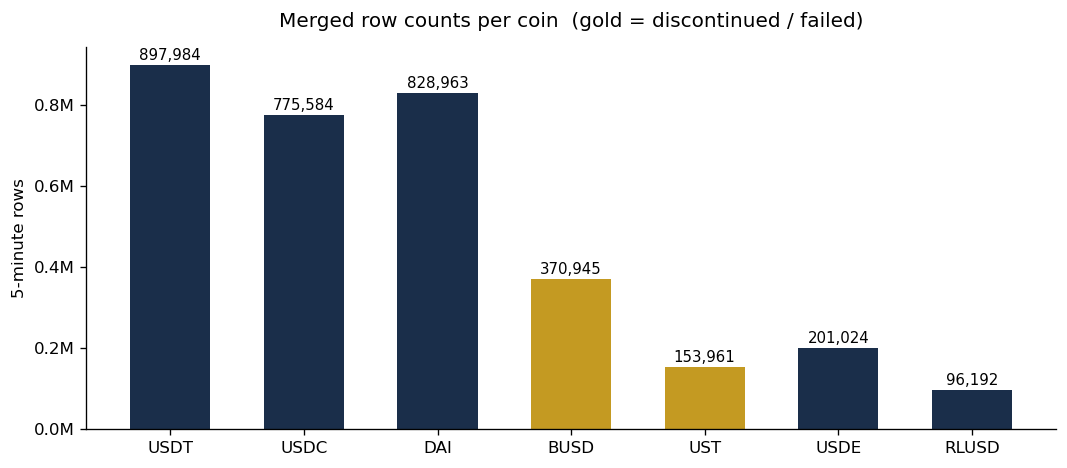

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
coins_list = list(merged.keys())
counts = [len(merged[c]) for c in coins_list]
colors = ["#1A2E4A" if c not in ("ust", "busd") else "#C49A22" for c in coins_list]
bars = ax.bar([c.upper() for c in coins_list], counts, color=colors, width=0.6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_ylabel("5-minute rows")
ax.set_title("Merged row counts per coin  (gold = discontinued / failed)", pad=12)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f"{count:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Null Rate by Source Group
Event-based sources (on-chain, Curve) are sparse by design — most 5-minute bars have no events. This is expected and will be zero-filled in the next stage.

In [10]:
PREFIX_GROUPS = {
    "CoinAPI (price)":   lambda c: c.startswith("coinapi_"),
    "Binance (market)":  lambda c: c.startswith("binance_"),
    "On-chain ETH":      lambda c: any(c.startswith(p) for p in ["mint_", "burn_", "net_flow", "treasury"]),
    "TRON treasury":     lambda c: c.startswith("tron_"),
    "Curve DEX":         lambda c: c.startswith("curve_"),
    "XRPL":              lambda c: c.startswith("xrpl_"),
    "Solana":            lambda c: c.startswith("sol_"),
    "FRED macro":        lambda c: c in ["dxy", "vix", "t10y", "fedfunds"],
    "Market / sentiment":lambda c: c in ["binance_btc_close", "binance_eth_close", "fear_greed"],
}

null_rows = []
for coin, df in merged.items():
    row = {"coin": coin.upper()}
    for group, pred in PREFIX_GROUPS.items():
        cols = [c for c in df.columns if pred(c)]
        row[group] = f"{df[cols].isnull().mean().mean():.0%}" if cols else "—"
    null_rows.append(row)

pd.DataFrame(null_rows).set_index("coin").style.set_caption(
    "Null rate by source group (event sources are sparse by design)"
).set_table_styles(
    [{"selector": "th", "props": [("background-color", "#1A2E4A"), ("color", "white")]}]
)

,CoinAPI (price),Binance (market),On-chain ETH,TRON treasury,Curve DEX,XRPL,Solana,FRED macro,Market / sentiment
coin,,,,,,,,,
USDT,0%,18%,99%,99%,69%,—,—,0%,2%
USDC,0%,8%,50%,—,64%,—,81%,0%,0%
DAI,0%,0%,49%,—,67%,—,—,0%,0%
BUSD,0%,0%,99%,—,100%,—,—,0%,0%
UST,0%,0%,—,—,100%,—,—,0%,0%
USDE,0%,0%,89%,—,74%,—,—,0%,0%
RLUSD,1%,0%,100%,—,92%,98%,—,0%,0%


## 7. Sample Rows — USDT
Quick sanity check on the merged output.

In [11]:
df_usdt = merged["usdt"]
# Show a sample from the UST collapse period (May 2022) — a stress event worth inspecting
sample = df_usdt.loc["2022-05-08":"2022-05-10", 
    [c for c in df_usdt.columns if any(c.startswith(p) 
     for p in ["coinapi_", "binance_btc", "dxy", "vix"])]
].head(10)
sample

,coinapi_open,coinapi_high,coinapi_low,coinapi_close,coinapi_tick_count,binance_btc_close,dxy,vix
timestamp,,,,,,,,
2022-05-08 00:00:00+00:00,0.999929,1.000007,0.999730,0.999972,0.0,35401.95,119.8577,30.19
2022-05-08 00:05:00+00:00,0.999952,0.999952,0.999758,0.999952,0.0,35487.78,119.8577,30.19
2022-05-08 00:10:00+00:00,0.999731,0.999952,0.999731,0.999952,0.0,35455.52,119.8577,30.19
2022-05-08 00:15:00+00:00,0.999924,0.999951,0.999758,0.999758,0.0,35373.88,119.8577,30.19
2022-05-08 00:20:00+00:00,0.999705,0.999951,0.999705,0.999758,0.0,35371.48,119.8577,30.19
2022-05-08 00:25:00+00:00,0.999705,0.999951,0.999705,0.999951,0.0,35339.76,119.8577,30.19
2022-05-08 00:30:00+00:00,0.999951,0.999951,0.999897,0.999897,0.0,35318.22,119.8577,30.19
2022-05-08 00:35:00+00:00,0.999951,0.999951,0.999704,0.999756,0.0,35303.08,119.8577,30.19
2022-05-08 00:40:00+00:00,0.999756,0.999951,0.999704,0.999951,0.0,35261.65,119.8577,30.19


## 8. Next Step
Run `02_clean_merged_data.ipynb` to:
- Zero-fill sparse event columns (on-chain, Curve)
- Forward-fill any remaining daily source gaps
- Apply depeg labels (`depeg`, `depeg_next_1h`)